# Notebook 02: Issue Detection

Detect non-compliance, adverse events, outcome anomalies, dosage instability, and declining patients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data_loader import load_data
from src.issue_detection import (
    detect_non_compliance, detect_adverse_events,
    detect_outcome_anomalies, detect_dosage_anomalies,
    detect_declining_patients, run_all_detections
)

df = load_data('../data/clinical_trial_data.csv')
print(f'Loaded {len(df)} records')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Loaded 6000 records


## 1. Non-Compliance Detection

Non-compliant records: 368
Patients affected: 72

Severity distribution:
severity
low       279
medium     89
Name: count, dtype: int64


/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_75381/1014057367.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_compliant, x='severity', y='outcome_score', ax=axes[1], palette='Reds_r')


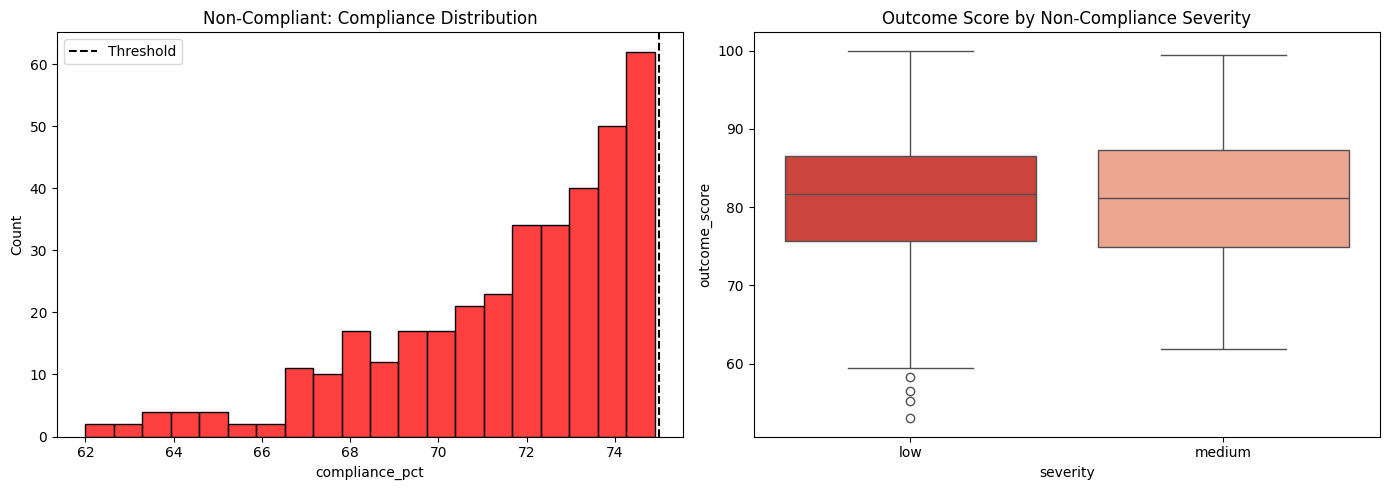

In [3]:
non_compliant = detect_non_compliance(df, threshold=75.0)
print(f'Non-compliant records: {len(non_compliant)}')
print(f'Patients affected: {non_compliant["patient_id"].nunique()}')
print(f'\nSeverity distribution:')
print(non_compliant['severity'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(non_compliant['compliance_pct'], bins=20, ax=axes[0], color='red')
axes[0].set_title('Non-Compliant: Compliance Distribution')
axes[0].axvline(75, color='black', linestyle='--', label='Threshold')
axes[0].legend()

sns.boxplot(data=non_compliant, x='severity', y='outcome_score', ax=axes[1], palette='Reds_r')
axes[1].set_title('Outcome Score by Non-Compliance Severity')
plt.tight_layout()
plt.show()

## 2. Adverse Event Detection

Adverse event records: 665
Patients affected: 194

Severity distribution:
severity
low       401
medium    258
high        6
Name: count, dtype: int64


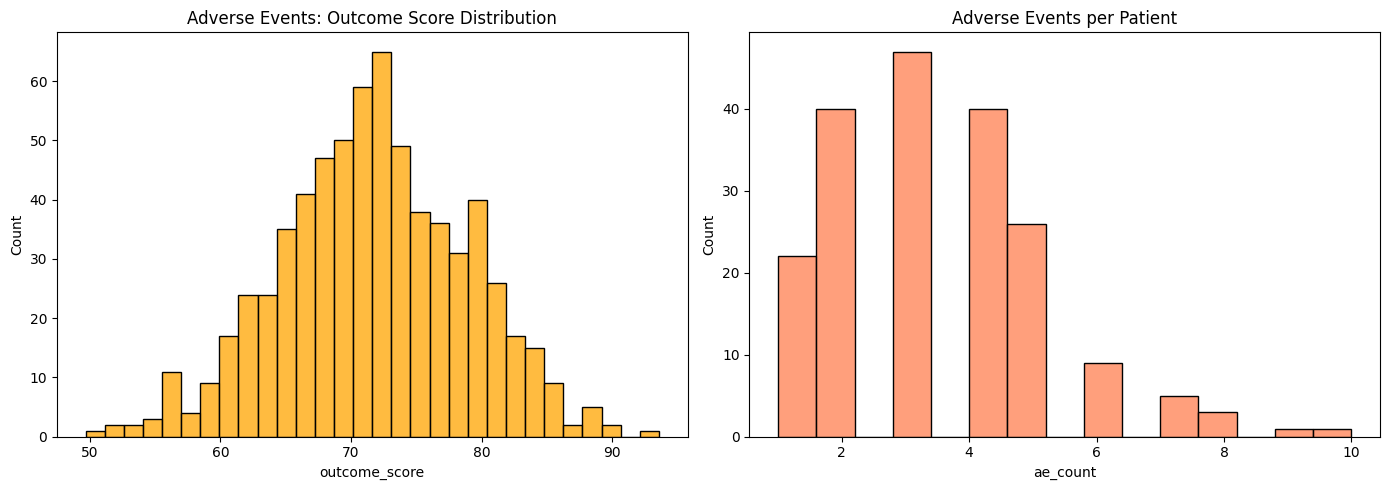

In [4]:
adverse = detect_adverse_events(df)
print(f'Adverse event records: {len(adverse)}')
print(f'Patients affected: {adverse["patient_id"].nunique()}')
print(f'\nSeverity distribution:')
print(adverse['severity'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(adverse['outcome_score'], bins=30, ax=axes[0], color='orange')
axes[0].set_title('Adverse Events: Outcome Score Distribution')

# Adverse events per patient
ae_per_patient = adverse.groupby('patient_id').size().reset_index(name='ae_count')
sns.histplot(ae_per_patient['ae_count'], bins=15, ax=axes[1], color='coral')
axes[1].set_title('Adverse Events per Patient')
plt.tight_layout()
plt.show()

## 3. Outcome Anomaly Detection

Anomalous records: 222
Patients affected: 127


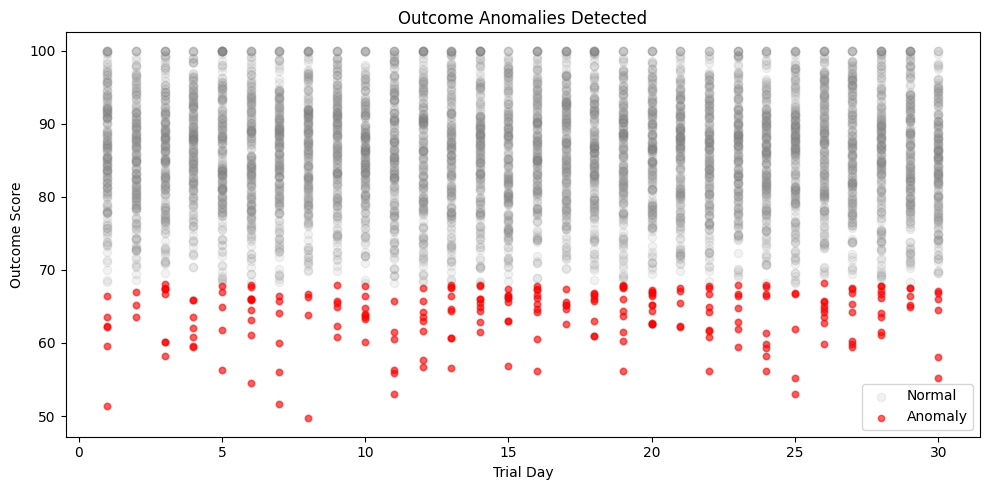

In [5]:
anomalies = detect_outcome_anomalies(df, z_threshold=2.0)
print(f'Anomalous records: {len(anomalies)}')
print(f'Patients affected: {anomalies["patient_id"].nunique()}')

if len(anomalies) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(df['trial_day'], df['outcome_score'], alpha=0.1, label='Normal', color='gray')
    ax.scatter(anomalies['trial_day'], anomalies['outcome_score'], color='red', alpha=0.6, label='Anomaly', s=20)
    ax.set_xlabel('Trial Day')
    ax.set_ylabel('Outcome Score')
    ax.set_title('Outcome Anomalies Detected')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Dosage Instability Detection

In [6]:
dosage_anom = detect_dosage_anomalies(df)
if len(dosage_anom) > 0:
    print(f'Dosage instability records: {len(dosage_anom)}')
    print(f'Patients affected: {dosage_anom["patient_id"].nunique()}')
else:
    print('No dosage instability detected.')

Dosage instability records: 5760
Patients affected: 192


## 5. Declining Patient Detection

Declining patients: 38
   patient_id cohort  score_trend  latest_score severity
0        P004      B        -6.78         87.46   medium
1        P006      B        -5.92         88.01   medium
2        P007      B       -12.95         71.65     high
3        P016      B        -8.30         79.97   medium
4        P017      A        -6.49         81.82   medium
5        P018      A        -5.69         83.22   medium
6        P022      B        -8.04         81.35   medium
7        P024      B        -5.50         75.79   medium
8        P026      A        -6.74         82.69   medium
9        P043      B       -10.72         94.25     high
10       P048      A        -6.39         90.44   medium
11       P051      A        -7.27         85.49   medium
12       P052      B       -11.34         82.00     high
13       P073      B        -8.37         92.46   medium
14       P074      B        -8.03         69.91   medium
15       P077      B        -5.47         96.07   medium
16      

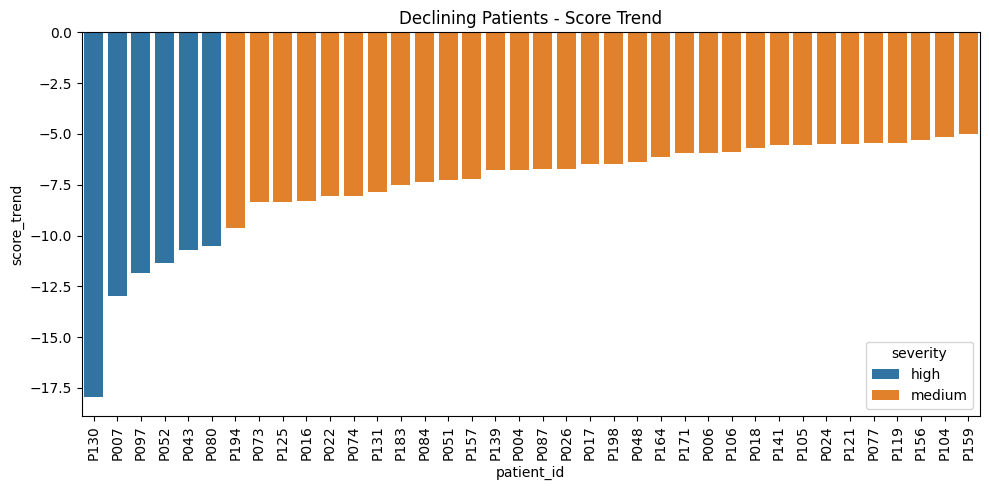

In [7]:
declining = detect_declining_patients(df)
if len(declining) > 0:
    print(f'Declining patients: {len(declining)}')
    print(declining[['patient_id', 'cohort', 'score_trend', 'latest_score', 'severity']].head(20))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=declining.sort_values('score_trend'), x='patient_id', y='score_trend', 
                hue='severity', dodge=False, ax=ax)
    ax.set_title('Declining Patients - Score Trend')
    ax.tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('No declining patients detected.')

## 6. Comprehensive Detection Report

In [8]:
results = run_all_detections(df)

print('=== ISSUE DETECTION SUMMARY ===')
print(f'Total records analyzed: {results["summary"]["total_records_analyzed"]}')
print(f'Total patients: {results["summary"]["total_patients"]}')
print(f'Total issues found: {results["summary"]["total_issues_found"]}')
print()
for key in ['non_compliance', 'adverse_events', 'outcome_anomalies', 'dosage_anomalies', 'declining_patients']:
    r = results[key]
    print(f'{key}: {r["count"]} issues, {r["patients_affected"]} patients affected')

=== ISSUE DETECTION SUMMARY ===
Total records analyzed: 6000
Total patients: 200
Total issues found: 7053

non_compliance: 368 issues, 72 patients affected
adverse_events: 665 issues, 194 patients affected
outcome_anomalies: 222 issues, 127 patients affected
dosage_anomalies: 5760 issues, 192 patients affected
declining_patients: 38 issues, 38 patients affected


## Key Findings

- Non-compliance issues cluster below 75% threshold with varying severity
- Adverse events affect approximately 10% of visits with clear outcome impact
- Statistical anomalies in outcome scores identified using z-score method
- Declining patient trajectories captured for early intervention